In [175]:
import pandas as pd

df = pd.read_csv('car_purchasing.csv', encoding='utf-8-sig')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB


In [176]:
df['debt_to_income'] = df['credit card debt'] / df['annual Salary']

In [177]:
X = df[['age', 'annual Salary', 'credit card debt', 'net worth', 'debt_to_income']]
y = df['car purchase amount']
X.head()

,age,annual Salary,credit card debt,net worth,debt_to_income
0,41.851720,62812.09301,11609.380910,238961.2505,0.184827
1,40.870623,66646.89292,9572.957136,530973.9078,0.143637
2,43.152897,53798.55112,11160.355060,638467.1773,0.207447
3,58.271369,79370.03798,14426.164850,548599.0524,0.181758
4,57.313749,59729.15130,5358.712177,560304.0671,0.089717


In [178]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [179]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [180]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [181]:
y_pred = lr.predict(X_test_scaled)

c:\Users\rdarc\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\rdarc\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


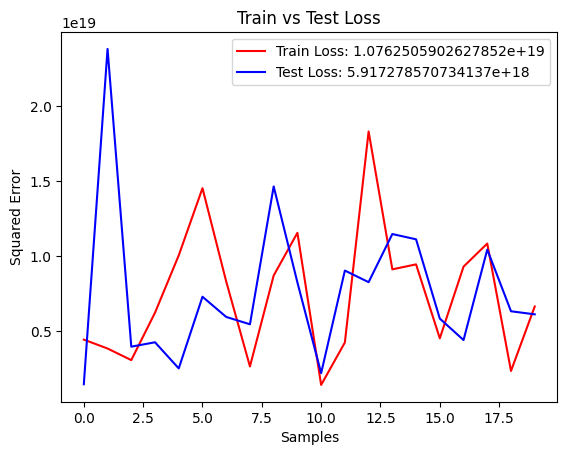

In [182]:
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error as mse
import numpy as np
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)
train_errors = (y_train - y_pred_train) ** 2
test_errors = (y_test - y_pred_test) ** 2
x_train = np.arange(len(train_errors))
x_test = np.arange(len(test_errors))

plt.plot(x_train[:20], train_errors[:20], color="red", label=f"Train Loss: {train_errors.iloc[-1]}")
plt.plot(x_test[:20], test_errors[:20], color="blue", label=f"Test Loss: {test_errors.iloc[-1]}")
plt.xlabel("Samples")
plt.ylabel("Squared Error")
plt.title("Train vs Test Loss")
plt.legend()

plt.show()